### Овсянникова Майя группа 241, 12.03.2026

### Условие задачи

Построить модель кластеризации (реализовать `KMeans` на своих наборах данных)

### Теория



Выбрала признаки для кластеризации признаки, масштабировала данные с помощью `StandardScaler`, чтобы привести все признаки к единому масштабу. В качестве метрики расстояния использовала евклидово расстояние. Для выбора оптимального количества кластеров применила метод локтя (по графику инерции) и метод силуэта. На основе их результатов выбрала `k = 3`. Обучила модель кластеризации и визуализировала результаты, используя `PCA` для уменьшения размерности

Полученные кластеры были проанализированы и интерпретированы как 3 характерные группы студентов

### Документация

- `preprocessing.StandardScaler` Стандартизирует признаки. Для каждого числового столбца он вычитает среднее значение и делит на стандартное отклонение. В результате все признаки имеют среднее = 0 и дисперсию = 1. Это необходимо для корректной работы `KMeans`, так как алгоритм основан на вычислении расстояний

- `cluster.KMeans` Строит модель кластеризации методом k-средних (`k-means`)

Суть модели кластеризации: алгоритм итеративно разбивает данные на заданное количество кластеров, на каждом шаге вычисляются центроиды кластеров (средние значения всех точек в кластере), а затем каждая точка данных относится к тому кластеру, расстояние до центроида которого минимально. Цель алгоритма: минимизировать сумму квадратов расстояний от точек до центроидов своих кластеров (= инерцию)

- `decomposition.PCA` Снижает размерность данных, находя главные компоненты, что позволяет удобно визуализировать многомерные данные на плоскости, сохранив как можно больше информации

- `metrics.silhouette_score` Вычисляет средний коэффициент силуэта — показывает, насколько хорошо каждый объект соответствует своему кластеру по сравнению с соседними. Значения от -1 до 1, чем ближе к 1, тем лучше качество кластеризации

- `inertia_` Свойство обученной модели KMeans — возвращает сумму квадратов расстояний от точек до центроидов их кластеров (`WCSS`), используется для метода локтя

### Решение

#### Загрузка данных и импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv('student_lifestyle_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   object 
 7   Gender                           2000 non-null   object 
 8   Grades                           2000 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 140.8+ KB


Для кластеризации образа жизни выберем все колонки, связанные с распределением времени:
- `Study_Hours_Per_Day`
- `Extracurricular_Hours_Per_Day`
- `Sleep_Hours_Per_Day`
- `Social_Hours_Per_Day`
- `Physical_Activity_Hours_Per_Day`

Grades могут быть зависимой переменной, их мы не включаем в кластеризацию, но потом посмотрим на их распределение по кластерам

In [2]:
features_for_clustering = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]

X = df[features_for_clustering]

K-means чувствителен к масштабу признаков, так как основан на расстояниях. Если один признак измеряется в единицах, а другой в десятках, то больший признак будет доминировать, поэтому сразу же масштабируем, используя `StandardScaler` (приводит к среднему 0 и дисперсии 1)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Масштабированные данные:")
print(X_scaled)

Масштабированные данные:
[[-0.40448677  1.56624592  0.82073377  0.05654313 -1.00589562]
 [-1.52845139  1.30663281  0.34147317  0.88588186 -0.52847018]
 [-1.66894696  1.65278363  1.16306277 -0.89127256  0.10809708]
 ...
 [-0.89622129 -1.72218687 -0.89091121 -1.12822648  2.57479519]
 [ 0.4384867  -1.11642293  0.06760998  0.47121249 -0.09083019]
 [ 1.0707168  -0.25104588 -0.13778742  0.23425857 -0.56825563]]


#### Выбор метрики расстояния

Метрику выберем стандартно – **Евклидово расстояние**

Это стандартная и наиболее распространенная метрика для K-means, так как алгоритм минимизирует сумму квадратов евклидовых расстояний (инерцию). Наши признаки после масштабирования становятся сравнимыми и имеют нормальное распределение (примерно), что делает евклидово расстояние оптимальной мерой

#### Выбор оптимального количества кластеров

Используем два метода:
1. **Метод локтя (Elbow method)** – график зависимости инерции WCSS от k
2. **Метод силуэта (Silhouette analysis)** – коэффициент силуэта (чем выше, тем лучше)

In [4]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

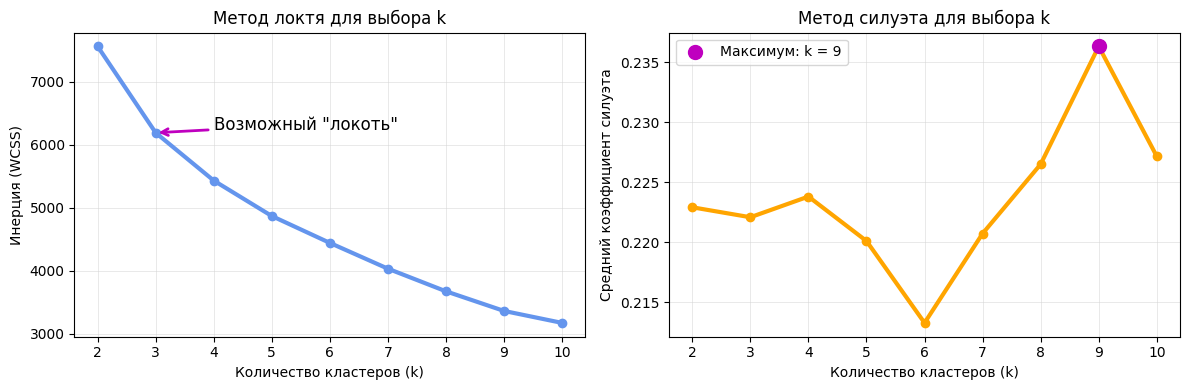

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertia, marker='o', linestyle='-', linewidth=3, color='cornflowerblue')
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Инерция (WCSS)')
axes[0].set_title('Метод локтя для выбора k')
axes[0].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
axes[0].annotate('Возможный "локоть"', xy=(3, inertia[1]), xytext=(4, inertia[1]+50), arrowprops=dict(arrowstyle='->', linewidth=2, color='m'), fontsize=12)

axes[1].plot(K_range, silhouette_scores, marker='o', linestyle='-', linewidth=3, color='orange')
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Средний коэффициент силуэта')
axes[1].set_title('Метод силуэта для выбора k')
axes[1].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
axes[1].scatter(9,silhouette_scores[7], color='m', s=100, zorder=5, label=f'Максимум: k = 9')
axes[1].legend()

plt.tight_layout()
plt.show()


Метод локтя показывает замедление падения инерции после `k = 3`, метод силуэта  показывает максимум при `k = 9`

При выборе `k` равным 9 получится разбиение на 9 "групп" студентов, что сложно содержательно различить и описать, также может привести к пересегментации

Оптимальным `k` было выбрано значение 3

In [6]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

df['Cluster'] = kmeans_final.labels_

#### Визуализация результатов

**PCA проекция**

Так как у нас многомерные данные (5 признаков), нам нужно уменьшить размерность для визуализации на плоскости. Используем **PCA (Principal Component Analysis)** для проекции на 2 главные компоненты

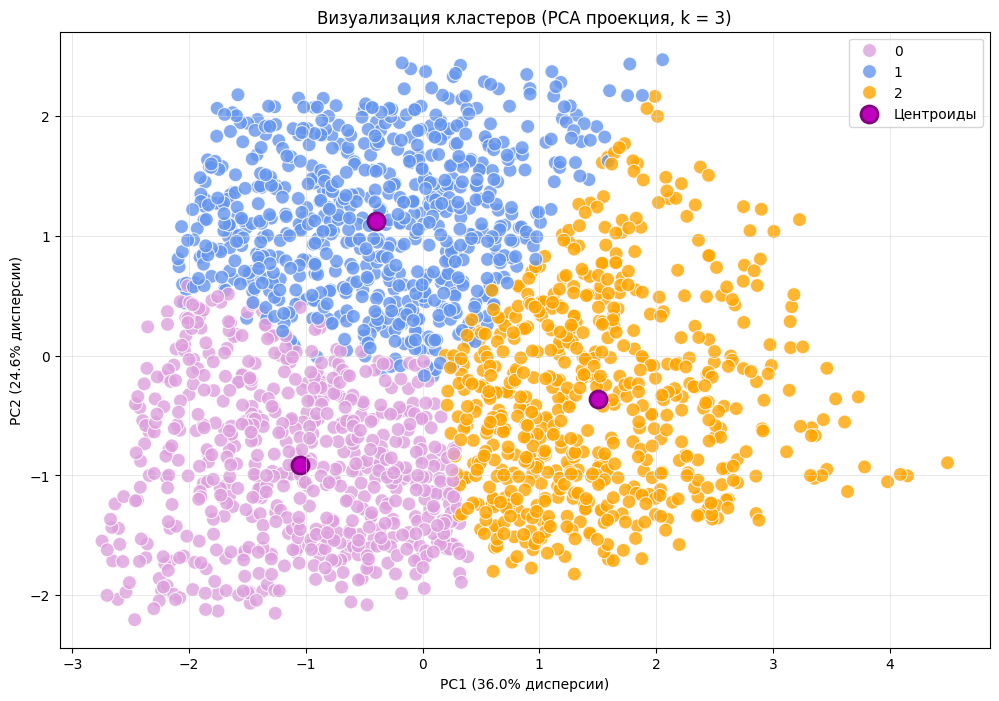

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
viz_df['Cluster'] = df['Cluster'].values
viz_df['Gender'] = df['Gender'].values
viz_df['Stress_Level'] = df['Stress_Level'].values
viz_df['Grades'] = df['Grades'].values

plt.figure(figsize=(12, 8))

cluster_colors = ['plum', 'cornflowerblue', 'orange']
sns.scatterplot(data=viz_df, x='PC1', y='PC2', hue='Cluster', palette=cluster_colors, s=100, alpha=0.8)

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='o', s=150, c='m', edgecolor='purple', linewidth=2, label='Центроиды')

plt.title(f'Визуализация кластеров (PCA проекция, k = {3})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.legend()

plt.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
plt.show()

#### Вклад признаков в главные компоненты

In [9]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features_for_clustering)

display(loadings.round(2))

,PC1,PC2
Study_Hours_Per_Day,-0.43,-0.14
Extracurricular_Hours_Per_Day,-0.31,-0.22
Sleep_Hours_Per_Day,-0.41,-0.36
Social_Hours_Per_Day,-0.15,0.87
Physical_Activity_Hours_Per_Day,0.73,-0.20


##### Сводка по кластерам

In [10]:
cluster_summary = df.groupby('Cluster').agg({**{feat: 'mean' for feat in features_for_clustering}, 'Grades': 'mean', 'Student_ID': 'count'}).rename(columns={'Student_ID': 'Count'})

display(cluster_summary.round(2))

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades,Count
Cluster,,,,,,,
0,8.40,2.51,8.60,1.61,2.87,8.11,638
1,7.36,1.92,7.21,4.49,3.03,7.76,724
2,6.68,1.56,6.73,1.77,7.26,7.50,638


##### Визуализируем профили кластеров

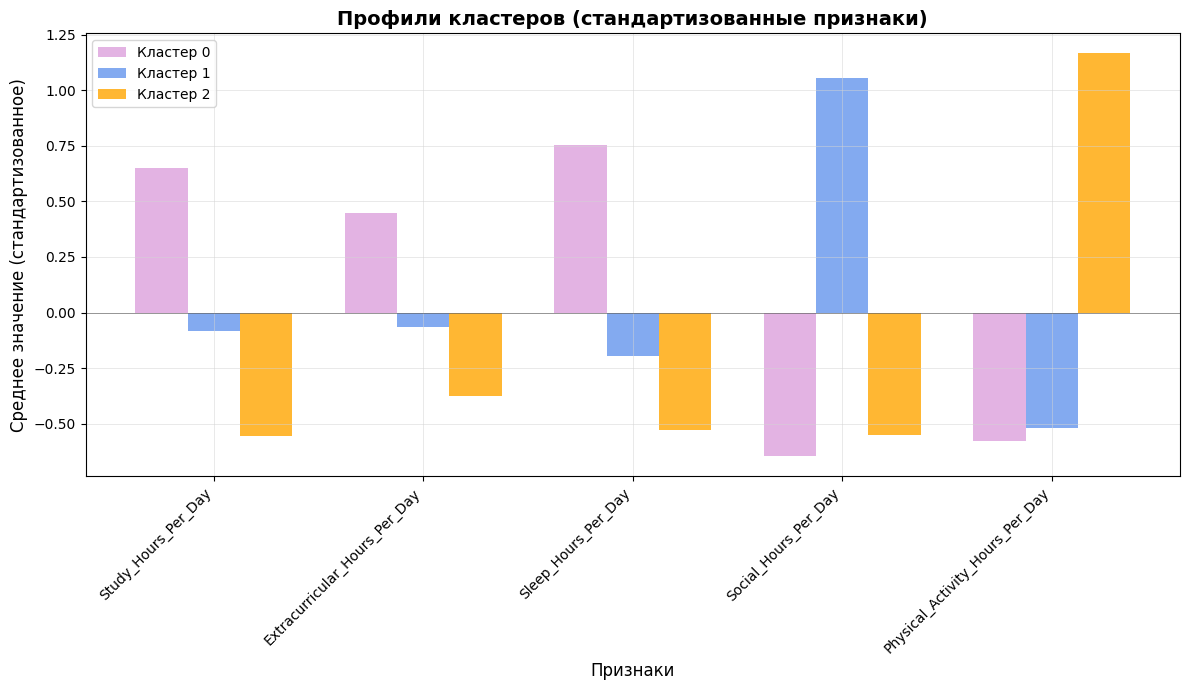

In [11]:
cluster_centers_scaled = pd.DataFrame(kmeans_final.cluster_centers_, columns=features_for_clustering).T
colors = ['plum', 'cornflowerblue', 'orange']

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(cluster_centers_scaled.index))
width = 0.25

for i, color in enumerate(colors):
    ax.bar(x + i*width, cluster_centers_scaled.iloc[:, i], width, label=f'Кластер {i}', color=color, alpha=0.8)

ax.set_xlabel('Признаки', fontsize=12)
ax.set_ylabel('Среднее значение (стандартизованное)', fontsize=12)
ax.set_title('Профили кластеров (стандартизованные признаки)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(cluster_centers_scaled.index, rotation=45, ha='right')
ax.legend()
ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

#### **Выводы**

Выделяются 3 характерные группы:
- **Отличники** – студенты, кторые много времени тратят на учебу, внеклассные дополнительные занятия, хорошо спят, меньше всех общаются и занимаются спортом
- **Социально активные студенты** – лидеры в количестве часов общения в сутки и "среднячки" в остальном
- **Спортсмены** – студенты, которые большинство времени уделяют спорту, а также имеют наименьшие остальные хаарктеристики

Такая классификация студентов очень логично может быть "в реальности" и мне кажется модель классификации получила отличный результат, четко выделив кластеры